In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.cm as cm
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score,classification_report
from sklearn.metrics import PrecisionRecallDisplay
from tensorflow.keras.preprocessing import image


In [15]:
JSON_PATH = r'C:\Users\athul\lego\minifigs.json'
IMAGE_DIR = r'C:\Users\athul\lego'  #parent folder for the images
IMG_SIZE = (260, 260)
BATCH_SIZE = 16

with open(JSON_PATH, 'r') as f:
    df = pd.DataFrame(json.load(f))

df['img_local_path'] = df['img_local_path'].astype(str).str.replace('\\', '/', regex=False)

counts = df['category'].value_counts()
valid_categories = counts[counts >= 5].index
print(f"Total images: {len(df)}")

#ensure categories have at least 5 images so we can stratify the split later on
df = df[df['category'].isin(valid_categories)]

print(f"Remaining cats: {len(valid_categories)}")
print(f"images left: {len(df)}")

import os

def check_exists(path):
    full_path = os.path.join(IMAGE_DIR, path)
    return os.path.exists(full_path)

#remove corrupted files
initial_count = len(df)
df = df[df['img_local_path'].apply(check_exists)]
final_count = len(df)

print(f"Removed {initial_count - final_count} corrupted/missing path(s).")
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

mlb = MultiLabelBinarizer()
theme_matrix = mlb.fit_transform(df['themes'])

theme_df = pd.DataFrame(theme_matrix, columns=mlb.classes_)

df_final = pd.concat([df[['img_local_path']], theme_df], axis=1)
MULTI_LABELS = list(mlb.classes_)

df_final['img_local_path'] = df_final['img_local_path'].astype(str)
df_final = df_final[df_final['img_local_path'] != 'nan']

df_final[MULTI_LABELS] = df_final[MULTI_LABELS].fillna(0)

df_final[MULTI_LABELS] = df_final[MULTI_LABELS].astype('float32')

nan_count = df_final[MULTI_LABELS].isnull().sum().sum()
print(f"Total NaNs in labels: {nan_count}") 

invalid_values = df_final[~df_final[MULTI_LABELS].isin([0, 1]).all(axis=1)]
print(f"Rows with invalid label values: {len(invalid_values)}")

theme_counts = df_final[MULTI_LABELS].sum().sort_values(ascending=False)

#Pick only themes with 30+ images
MAJOR_LABELS = theme_counts[theme_counts >= 30].index.tolist()

Total images: 17362
Remaining cats: 111
images left: 17339
Removed 1 corrupted/missing path(s).
Total NaNs in labels: 0
Rows with invalid label values: 0


In [16]:

labels_list = list(MAJOR_LABELS)

# eparate 10% for the TEST set
msss_test = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

X = df_final.index.values
y = df_final[labels_list].values

for train_val_idx, test_idx in msss_test.split(X, y):
    df_train_val = df_final.iloc[train_val_idx].copy()
    df_test = df_final.iloc[test_idx].copy()

# Train (~72%), Eval (~18%), Test (10%)
X_tv = df_train_val.index.values
y_tv = df_train_val[labels_list].values

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in msss_val.split(X_tv, y_tv):
    train_df = df_train_val.iloc[train_idx].copy()
    val_df = df_train_val.iloc[val_idx].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(df_test)}")

Train: 12483 | Val: 3121 | Test: 1734


In [17]:


def build_model(num_classes=75):
    base = tf.keras.applications.EfficientNetB2(weights='imagenet', include_top=False, input_shape=(260, 260, 3))
    base.trainable = True
    for layer in base.layers[:-40]:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='swish', kernel_regularizer=regularizers.l2(0.01))(x) 
    x = layers.Dropout(0.5)(x) 
    predictions = layers.Dense(num_classes, activation='sigmoid')(x)
    
    return models.Model(inputs=base.input, outputs=predictions)


model3 = build_model(num_classes=75)
model3.load_weights('lego_weights_B2best.h5')

In [18]:
for i, layer in enumerate(model3.layers):
    print(f"Layer {i}: {layer.name} | Type: {type(layer).__name__} | Trainable: {layer.trainable}")

Layer 0: input_layer_3 | Type: InputLayer | Trainable: False
Layer 1: rescaling_6 | Type: Rescaling | Trainable: False
Layer 2: normalization_3 | Type: Normalization | Trainable: False
Layer 3: rescaling_7 | Type: Rescaling | Trainable: False
Layer 4: stem_conv_pad | Type: ZeroPadding2D | Trainable: False
Layer 5: stem_conv | Type: Conv2D | Trainable: False
Layer 6: stem_bn | Type: BatchNormalization | Trainable: False
Layer 7: stem_activation | Type: Activation | Trainable: False
Layer 8: block1a_dwconv | Type: DepthwiseConv2D | Trainable: False
Layer 9: block1a_bn | Type: BatchNormalization | Trainable: False
Layer 10: block1a_activation | Type: Activation | Trainable: False
Layer 11: block1a_se_squeeze | Type: GlobalAveragePooling2D | Trainable: False
Layer 12: block1a_se_reshape | Type: Reshape | Trainable: False
Layer 13: block1a_se_reduce | Type: Conv2D | Trainable: False
Layer 14: block1a_se_expand | Type: Conv2D | Trainable: False
Layer 15: block1a_se_excite | Type: Multiply | 

Weighted Loss function for handling Label Imbalance along with label smoothing which prevents the model from becoming overconfident and generalize better to noisy LEGO images
calculated weights based on the square root of the inverse frequency so rare themes get a higher weight (up to 15.0)
monitor val_auc rather than accuracy since it measures how well the model ranks the themes, regardless of the threshold
ReduceLROnPlateau - when the model stops improving, it cuts the learning rate by half (factor=0.5) to fine-tune the weights more delicately.

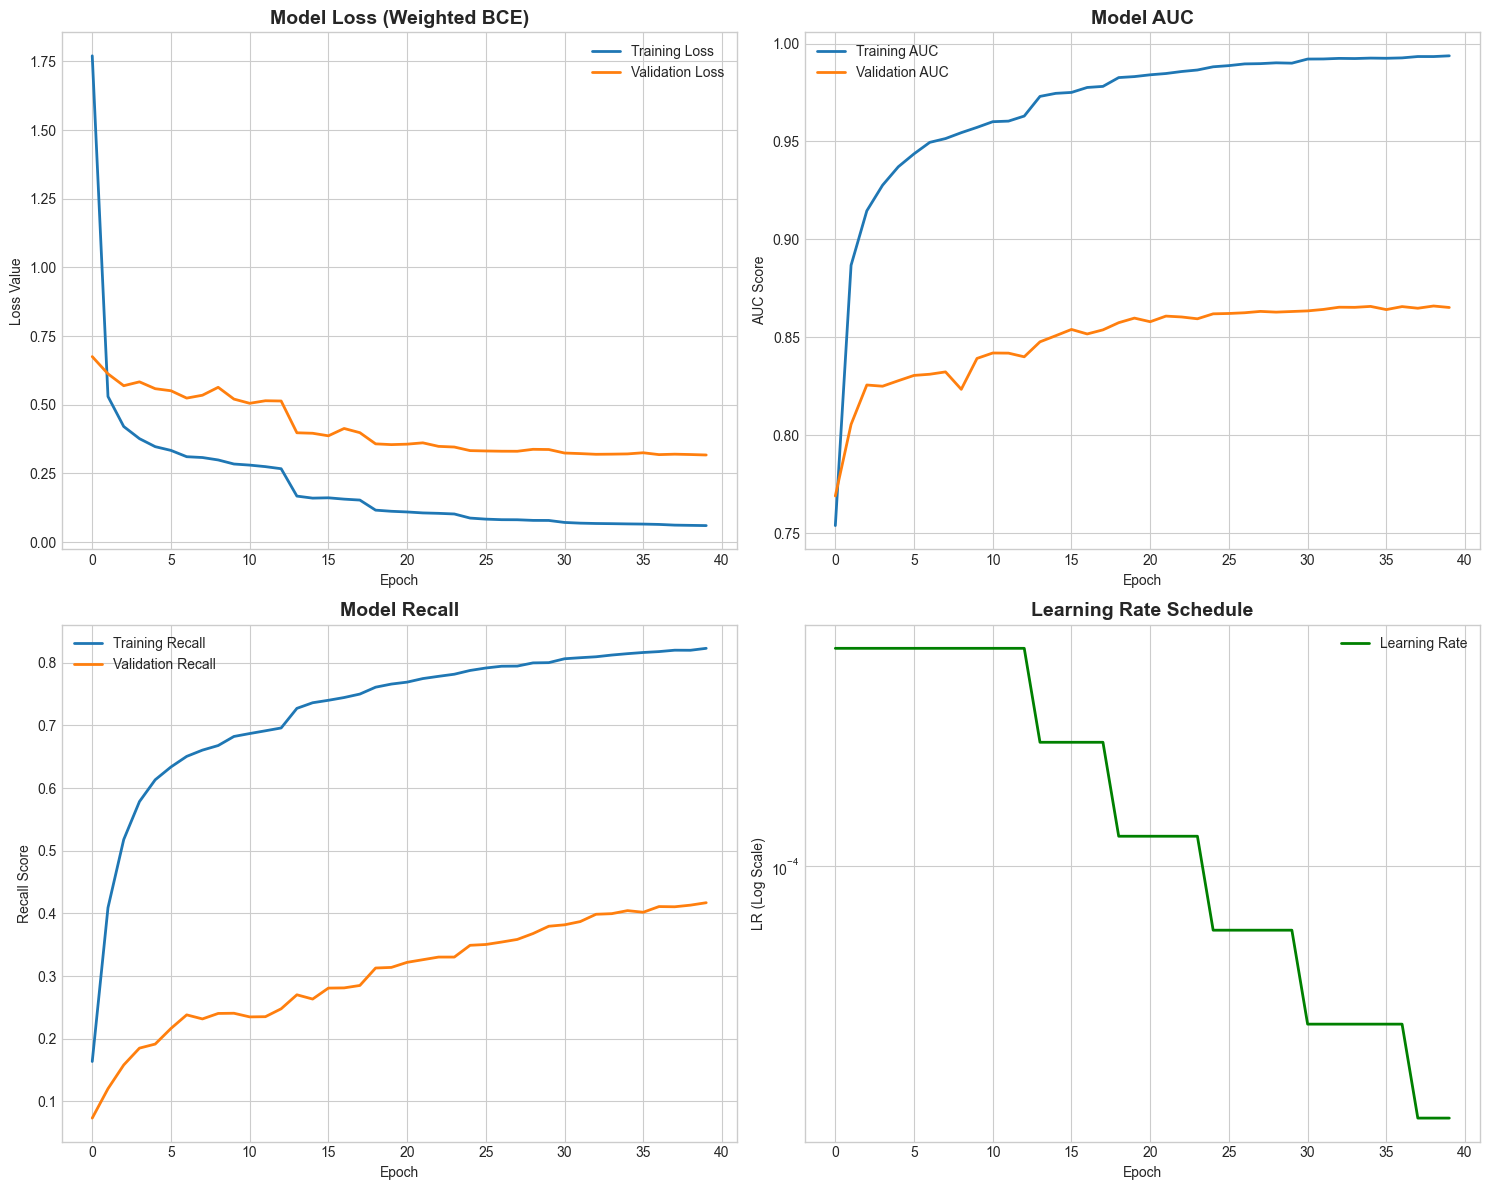

In [90]:
def plot_final_history(history):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Loss Plot: Weighted Binary Cross-Entropy
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Model Loss (Weighted BCE)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss Value')
    axes[0, 0].legend()

    # 2. AUC Plot
    axes[0, 1].plot(history.history['auc'], label='Training AUC', linewidth=2)
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
    axes[0, 1].set_title('Model AUC', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC Score')
    axes[0, 1].legend()

    # 3. Recall Plot
    axes[1, 0].plot(history.history['recall'], label='Training Recall', linewidth=2)
    axes[1, 0].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
    axes[1, 0].set_title('Model Recall', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall Score')
    axes[1, 0].legend()

    # 4. Learning Rate Plot
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', color='green', linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR (Log Scale)')
    axes[1, 1].set_yscale('log') #for seeing tiny LR changes
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

plot_final_history(history)

Model Loss - a massive plummet in training loss within the first 2 epochs with validation loss remaining consistently higher but still downward-trending 
after epoch 20, the curves flatten, suggesting the model has extracted most of the easy features and is struggling with subtle differences 
AUC measures the model's ability to rank themes correctly across all confidence thresholds and the model achieves solid training and validation AUCs 
a random LEGO set, there is an 87% chance it will rank the correct theme higher than a random incorrect one
orange line is much smoother than in the Recall graph showing that even if the model isn't 100% sure its relative confidence in the correct labels is very stable
Recall measures the model's ability to find all relevant themes in an image
Lower recall shows that the model is identifying the main theme easily, but is likely missing the more niche labels
Recall continues to climb steadily for the validation set throughout the entire 40 epochs -- could be improved?
ReduceLROnPlateau callback makes the learning rate drop in steps at epochs 12, 17, 24, 30, and 36
at the Model Loss graph at epoch 13—there is a noticeable dip in loss right after the first LR drop. 
When the model's progress stalled, the callback lowered the LR, allowing the optimizer to find a narrower, valley in the loss landscape.

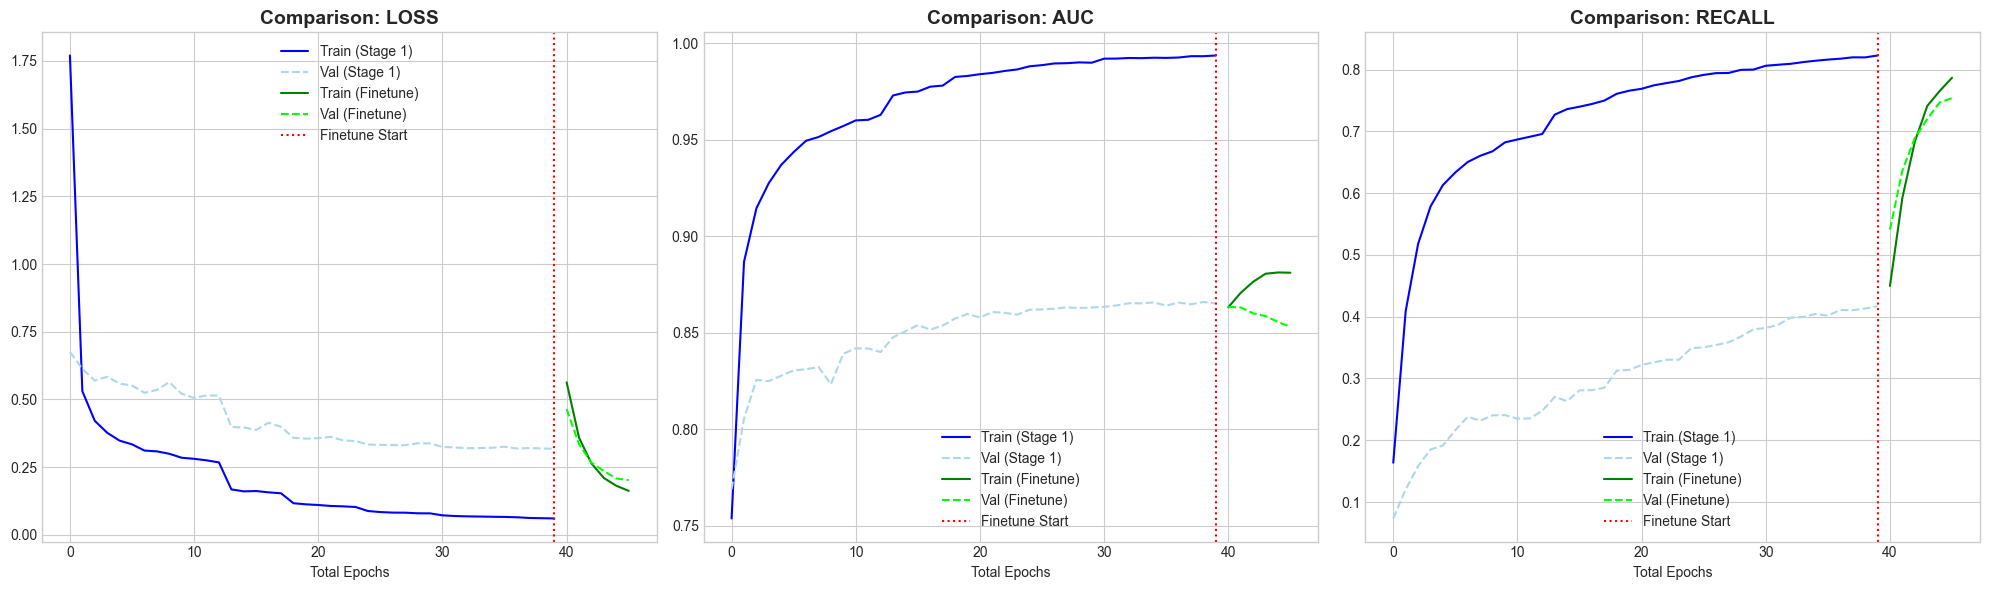

In [105]:
def plot_comparison(h1, h2):
    # Combine the metrics
    metrics = ['loss', 'auc', 'recall']
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for i, metric in enumerate(metrics):
        # Data from initial training
        train_h1 = h1.history[metric]
        val_h1 = h1.history[f'val_{metric}']
        
        # Data from fine-tuning
        train_h2 = h2.history[metric]
        val_h2 = h2.history[f'val_{metric}']
        
        # Create continuous x-axis
        total_epochs = len(train_h1) + len(train_h2)
        x_h1 = range(len(train_h1))
        x_h2 = range(len(train_h1), total_epochs)

        # Plot Stage 1
        axes[i].plot(x_h1, train_h1, label='Train (Stage 1)', color='blue')
        axes[i].plot(x_h1, val_h1, label='Val (Stage 1)', color='lightblue', linestyle='--')
        
        # Plot Stage 2
        axes[i].plot(x_h2, train_h2, label='Train (Finetune)', color='green')
        axes[i].plot(x_h2, val_h2, label='Val (Finetune)', color='lime', linestyle='--')

        # Vertical line for the transition
        axes[i].axvline(x=len(train_h1)-1, color='red', linestyle=':', label='Finetune Start')
        
        axes[i].set_title(f'Comparison: {metric.upper()}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Total Epochs')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_comparison(history, finetune)

In multi-label classification, the model often ignores rare classes to minimize average loss -> gamma ensures that if the model is only 20% confident in a correct LEGO theme, the loss is significantly higher than if it were 80% confident. Standard sets like City or Star Wars contribute less to the gradient as the model masters them, forcing the optimizer to spend its energy on visually ambiguous themes 
Validation Recall jumped from ~0.42 to 0.75 by Epoch 6 -> focal loss forced the model to lower its internal threshold for predicting a label. 
While Recall soared, val_auc slightly decreased as the model is becoming slightly more liberal with its guesses, more False Positives, dipping AUC

By using a learning rate 50x smaller than the initial phase the model has found more specific geometries of LEGO pieces 
significant increase in Validation Recall from 0.42 to 0.75 justifies the use of Focal Loss
slight decay in val_auc suggests maybe to try different thresholds for different themes to get better results 

In [6]:
MAJOR_LABELS = list(MAJOR_LABELS)

train_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0 
)


base_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator3 = train_datagen2.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    interpolation='lanczos',
    class_mode='other',
    validate_filenames=True
)

val_generator3 = base_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    class_mode='other'
)

val_df_fixed = val_df[['img_local_path'] + list(MAJOR_LABELS)]

eval_generator3 = base_datagen.flow_from_dataframe(
    dataframe=val_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS, 
    target_size=(260, 260),
    batch_size=16,
    class_mode="other",
    interpolation='lanczos',
    shuffle=False
)

test_df_fixed = df_test[['img_local_path'] + list(MAJOR_LABELS)]

# for F1, Confusion Matrix, and Predictions
test_generator3 = base_datagen.flow_from_dataframe(
    dataframe=test_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    class_mode="other",
    interpolation='lanczos',
    shuffle=False  
)

Found 12483 validated image filenames.
Found 3121 validated image filenames.
Found 3121 validated image filenames.
Found 1734 validated image filenames.


In [33]:

y_val_probs = model3.predict(eval_generator3) 
y_val_true = val_df_fixed[MAJOR_LABELS].values 

best_thresholds = []
for i in range(len(MAJOR_LABELS)):
    thresholds = np.linspace(0, 0.9, 100) 
    f1_scores = [f1_score(y_val_true[:, i], (y_val_probs[:, i] > t).astype(int)) for t in thresholds]
    
    best_t = thresholds[np.argmax(f1_scores)]
    best_thresholds.append(best_t)

y_val_pred_opt = np.zeros_like(y_val_probs)
for i in range(len(MAJOR_LABELS)):
    y_val_pred_opt[:, i] = (y_val_probs[:, i] > best_thresholds[i]).astype(int)

print("Optimized Macro F1:", f1_score(y_val_true, y_val_pred_opt, average='macro'))
print(classification_report(y_val_true, y_val_pred_opt, target_names=MAJOR_LABELS))

196/196 ━━━━━━━━━━━━━━━━━━━━ 131s 669ms/step
Optimized Macro F1: 0.7246135461286626
                              precision    recall  f1-score   support

                        City       0.24      0.63      0.35       359
                   Star Wars       0.28      0.52      0.37       265
                     Ninjago       0.31      0.34      0.32       167
                     Friends       0.94      0.82      0.88       158
                       Duplo       0.91      0.82      0.86       150
     Collectable Minifigures       0.27      0.27      0.27       141
         Marvel Super Heroes       0.22      0.34      0.26       127
                        Town       0.77      0.72      0.75       126
                Harry Potter       0.37      0.53      0.43       114
                      Castle       0.78      0.76      0.77        83
                   Education       0.77      0.62      0.69        82
                      Disney       0.34      0.54      0.42        69
     

C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


iterate through 100 possible thresholds for every theme to find the one that maximizes the F1-Score -> Optimized Macro F1 of 0.72 for eval set
Themes like Bionicle (1.00 F1), Technic (1.00 F1), Friends (0.88 F1), and Duplo (0.86 F1) have exceptionally high scores due to unique parts that create distinct activations 
Themes like City (0.35 F1), Star Wars (0.37 F1), and Marvel (0.26 F1) show high Recall but low Precision -> often feature standard-shaped bricks and generic art leading to over-prediction

Wicked (0.89 F1) or Games (0.95 F1) even with very low support (5–22) thanks to the Stratified Split and Weighted Loss are not getting drowned out 

high Macro F1 (0.72) compared to the Micro F1 (0.55) indicates that the model is performing excellently on a per-class basis, handling class imbalance 
lower precision in themes like Star Wars and Marvel Super Heroes is attributed to similar box art styles, creating overlapping feature activations 

UndefinedMetricWarning means that for a few images, the model didn't find any theme above the thresholds, or had no ground-truth labels.

In [28]:
val_support = val_df_fixed[MAJOR_LABELS].sum().sort_values(ascending=False)
top_55_names = val_support.head(55).index.tolist()
top_55_indices = [list(MAJOR_LABELS).index(name) for name in top_55_names]

y_true_55 = y_val_true[:, top_55_indices]
y_pred_55 = y_val_pred_opt[:, top_55_indices]

top_55_macro_f1 = f1_score(y_true_55, y_pred_55, average='macro')
print(f"Top 55 Themes F1: {top_55_macro_f1:.4f}")

Top 55 Themes F1: 0.6980


In [32]:
macro_f1    = f1_score(y_true_55, y_pred_55, average='macro')
weighted_f1 = f1_score(y_true_55, y_pred_55, average='weighted')
micro_f1    = f1_score(y_true_55, y_pred_55, average='micro')

print(f"METRICS SUMMARY (TOP 55 THEMES)")
print("="*50)
print(f"Macro F1 Score   : {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print(f"Micro F1 Score   : {micro_f1:.4f}")
print("\n")

print(f"CLASSIFICATION REPORT (TOP 55 THEMES)")
print("="*50)
print(classification_report(
    y_true_55, 
    y_pred_55, 
    target_names=top_55_names, 
    zero_division=0
))


METRICS SUMMARY (TOP 55 THEMES)
Macro F1 Score   : 0.6980
Weighted F1 Score: 0.5814
Micro F1 Score   : 0.5419


CLASSIFICATION REPORT (TOP 55 THEMES)
                              precision    recall  f1-score   support

                        City       0.25      0.62      0.35       359
                   Star Wars       0.30      0.46      0.36       265
                     Ninjago       0.25      0.46      0.32       167
                     Friends       0.94      0.82      0.88       158
                       Duplo       0.91      0.82      0.86       150
     Collectable Minifigures       0.29      0.25      0.27       141
         Marvel Super Heroes       0.22      0.33      0.26       127
                        Town       0.76      0.72      0.74       126
                Harry Potter       0.45      0.41      0.43       114
                      Castle       0.78      0.76      0.77        83
                   Education       0.77      0.62      0.69        82
         

On TEST data

In [82]:
y_test_probs = model3.predict(test_generator3)

y_test_pred_opt = np.zeros_like(y_test_probs)
for i in range(len(MAJOR_LABELS)):
    y_test_pred_opt[:, i] = (y_test_probs[:, i] > best_thresholds[i]).astype(int)

y_test_true = test_df_fixed[MAJOR_LABELS].values


overall_macro_f1 = f1_score(y_test_true, y_test_pred_opt, average='macro')

print(f"Overall Test Macro F1 (75 Themes): {overall_macro_f1:.4f}")
print("-" * 60)
print(classification_report(y_test_true, y_test_pred_opt, target_names=MAJOR_LABELS))

109/109 [==============================] - 30s 274ms/step
Overall Test Macro F1 (75 Themes): 0.6899
------------------------------------------------------------
                              precision    recall  f1-score   support

                        City       0.25      0.68      0.37       200
                   Star Wars       0.25      0.44      0.32       147
                     Ninjago       0.22      0.30      0.26        93
                     Friends       0.93      0.90      0.91        88
                       Duplo       0.82      0.82      0.82        84
     Collectable Minifigures       0.24      0.31      0.27        78
         Marvel Super Heroes       0.19      0.33      0.24        70
                        Town       0.81      0.73      0.77        70
                Harry Potter       0.33      0.36      0.34        64
                      Castle       0.87      0.74      0.80        46
                   Education       0.83      0.67      0.74        4

C:\Users\athul\anaconda3\envs\lego-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\athul\anaconda3\envs\lego-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\athul\anaconda3\envs\lego-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

Overall Macro F1 (0.6899): treats all 75 themes equally, regardless of how many images they have
Themes like City (0.68 Recall) and Star Wars (0.44 Recall) show that the model is biased toward finding these labels even if it gets them wrong  - visual diversity and high representation

High F1-scores in rare themes—such as Teenage Mutant Ninja Turtles (1.00), Despicable Me (1.00), and Wicked (0.86)—prove that the Focal Loss effectively forced the EfficientNetB2 backbone to learn niche visual features
drop of only ~3% between validation and test indicates that your model is not overfitted -> EarlyStopping and ReduceLROnPlateau worked
lower performance in themes like Marvel Super Heroes (0.24 F1) is justified by visual overlap to Star Wars or City sets 

Samples Avg F1 of 0.50 suggests that when a set has multiple labels, the model typically captures at least one or two correctly

In [35]:
test_support = test_df_fixed[MAJOR_LABELS].sum().sort_values(ascending=False)
top_55_names_test = test_support.head(55).index.tolist()
top_55_indices_test = [list(MAJOR_LABELS).index(name) for name in top_55_names_test]

y_test_true_55 = y_test_true[:, top_55_indices_test]
y_test_pred_55 = y_test_pred_opt[:, top_55_indices_test]

test_macro_f1    = f1_score(y_test_true_55, y_test_pred_55, average='macro')
test_weighted_f1 = f1_score(y_test_true_55, y_test_pred_55, average='weighted')
test_micro_f1    = f1_score(y_test_true_55, y_test_pred_55, average='micro')

print(f"TEST SET: METRICS SUMMARY (TOP 55 THEMES)")
print("="*50)
print(f"Macro F1 Score   : {test_macro_f1:.4f}")
print(f"Weighted F1 Score: {test_weighted_f1:.4f}")
print(f"Micro F1 Score   : {test_micro_f1:.4f}")
print("\n")


print(f"TEST CLASSIFICATION REPORT (TOP 55 THEMES)")
print("="*50)
print(classification_report(
    y_test_true_55, 
    y_test_pred_55, 
    target_names=top_55_names_test, 
    zero_division=0
))

TEST SET: METRICS SUMMARY (TOP 55 THEMES)
Macro F1 Score   : 0.6738
Weighted F1 Score: 0.5578
Micro F1 Score   : 0.5183


TEST CLASSIFICATION REPORT (TOP 55 THEMES)
                              precision    recall  f1-score   support

                        City       0.25      0.67      0.37       200
                   Star Wars       0.29      0.44      0.35       147
                     Ninjago       0.19      0.42      0.26        93
                     Friends       0.93      0.90      0.91        88
                       Duplo       0.84      0.76      0.80        84
     Collectable Minifigures       0.26      0.28      0.27        78
         Marvel Super Heroes       0.18      0.31      0.23        70
                        Town       0.80      0.74      0.77        70
                Harry Potter       0.43      0.30      0.35        64
                      Castle       0.87      0.74      0.80        46
                   Education       0.83      0.67      0.74     

Themes like City, Star Wars, and Marvel Super Heroes represent the bulk of your test data and exhibit high Recall but relatively low Precision 
By penalizing easy examples and focusing on hard ones, the model has become sensitive to common themes
Because these themes often use generic building elements the model casts a wide net and guess City and be wrong than miss one

Themes such as Friends (0.91 F1), Duplo (0.82 F1), and Belville (0.88 F1) maintain both Precision and Recall above 0.80.
possess unique visual signatures that are easily isolateble (distinct color schemes, rounded geometric proportions)

Themes like Castle (0.80 F1), Town (0.76 F1), and Space (0.82 F1) maintain high F1-scores
Even for themes with very few samples, like The Hobbit (0.83 F1) or Cars (0.80 F1), the model remains accurate.
Stratified Split strategy and using Weighted Loss to boost their importance has worked

C:\Users\athul\anaconda3\envs\bda3\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1045']]
Received: inputs=Tensor(shape=(1, 260, 260, 3))
  warnings.warn(msg)


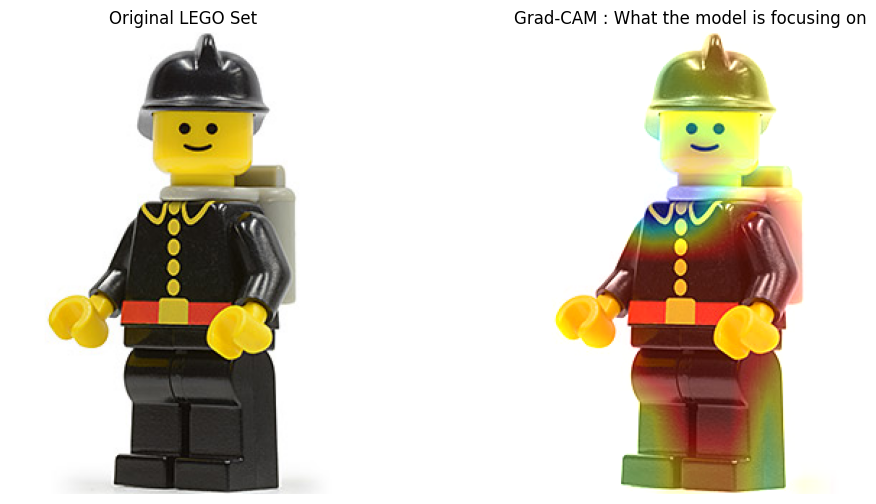

In [75]:
def preprocess_input_image(img_path, target_size=(260, 260)): 
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original LEGO Set")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM : What the model is focusing on")
    plt.axis('off')
    plt.show()

last_layer = [l.name for l in model3.layers if 'conv' in l.name or 'activation' in l.name][-1]

img_idx = 25
base_dir = r'C:\Users\athul\lego' 
relative_path = df_test.iloc[img_idx]['img_local_path'] 
sample_path = os.path.join(base_dir, relative_path)

img_input = preprocess_input_image(sample_path)
heatmap = get_gradcam_heatmap(model3, img_input, last_layer)
display_gradcam(sample_path, heatmap)

In [35]:
y_test_probs = model3.predict(test_generator3)
y_test_true = test_df_fixed[MAJOR_LABELS].values

results_data = []

for i, theme in enumerate(MAJOR_LABELS):
    y_true = y_test_true[:, i]
    y_probs = y_test_probs[:, i]
    
    # at 0.5 Threshold
    y_pred_05 = (y_probs > 0.5).astype(int)
    tn05, fp05, fn05, tp05 = confusion_matrix(y_true, y_pred_05, labels=[0, 1]).ravel()
    p05, r05, f05, _ = precision_recall_fscore_support(y_true, y_pred_05, average='binary', zero_division=0)
    acc05 = accuracy_score(y_true, y_pred_05)
    
    # at Optimal Threshold
    opt_t = best_thresholds[i]
    y_pred_opt = (y_probs > opt_t).astype(int)
    tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_true, y_pred_opt, labels=[0, 1]).ravel()
    p_opt, r_opt, f_opt, _ = precision_recall_fscore_support(y_true, y_pred_opt, average='binary', zero_division=0)
    acc_opt = accuracy_score(y_true, y_pred_opt)
    
    results_data.append({
        'Theme': theme,
        'Support': int(np.sum(y_true)),
        'Opt_Threshold': round(opt_t, 3),
        # at 0.5
        'TP_0.5': tp05, 'FP_0.5': fp05, 'TN_0.5': tn05, 'FN_0.5': fn05,
        'Prec_0.5': round(p05, 3), 'Rec_0.5': round(r05, 3), 'F1_0.5': round(f05, 3),
        # at Optimal
        'TP_Opt': tp_opt, 'FP_Opt': fp_opt, 'TN_Opt': tn_opt, 'FN_Opt': fn_opt,
        'Prec_Opt': round(p_opt, 3), 'Rec_Opt': round(r_opt, 3), 'F1_Opt': round(f_opt, 3),
        'Acc_Opt': round(acc_opt, 3)
    })

full_metrics_df = pd.DataFrame(results_data)
full_metrics_df

109/109 ━━━━━━━━━━━━━━━━━━━━ 73s 669ms/step
                       Theme  Support  Opt_Threshold  F1_0.5  F1_Opt  TP_Opt  FP_Opt
                        City      200          0.182   0.101   0.372     136     395
                   Star Wars      147          0.191   0.144   0.318      65     197
                     Ninjago       93          0.182   0.042   0.257      28      97
                     Friends       88          0.455   0.913   0.913      79       6
                       Duplo       84          0.682   0.821   0.800      64      12
     Collectable Minifigures       78          0.191   0.000   0.268      24      77
         Marvel Super Heroes       70          0.145   0.028   0.237      23     101
                        Town       70          0.600   0.768   0.767      51      12
                Harry Potter       64          0.173   0.113   0.343      23      47
                      Castle       46          0.382   0.819   0.800      34       5
                   Ed

City & Star Wars: At 0.5, City had an F1-score of only 0.101. By dropping the threshold to 0.182, the F1 nearly quadrupled to 0.372.
Themes like Collectable Minifigures and Disney had an F1 of 0.000 at the default threshold and lowering it helped them get identified 
City has 395 False Positives at the optimal threshold because it acts as the default visual category for the model. 
Friends (0.913 F1), Duplo (0.800 F1), and The LEGO Batman Movie (0.941 F1)
themes have such distinct visual features so the model is naturally confident and is above 0.5

Even though the Top 3 have lower F1s due to their complexity, the model's great performance on the other 50+ themes carries the global average. 

In [36]:
top_55_metrics_df = full_metrics_df.sort_values(by='Support', ascending=False).head(55)

comparison_columns = [
    'Theme', 'Support', 'Opt_Threshold', 
    'Prec_0.5', 'Rec_0.5', 'F1_0.5', 
    'Prec_Opt', 'Rec_Opt', 'F1_Opt',
    'TP_Opt', 'FP_Opt', 'FN_Opt'
]

print(top_55_metrics_df[comparison_columns].to_string(index=False))

mean_f1_05 = top_55_metrics_df['F1_0.5'].mean()
mean_f1_opt = top_55_metrics_df['F1_Opt'].mean()
print(f"\nAverage F1 at 0.5: {mean_f1_05:.4f}")
print(f"Average F1 at Optimal: {mean_f1_opt:.4f}")
print(f"Total Improvement for Top 55: {(mean_f1_opt - mean_f1_05):.4f}")

--- Detailed Performance Comparison: Top 55 Themes ---
                       Theme  Support  Opt_Threshold  Prec_0.5  Rec_0.5  F1_0.5  Prec_Opt  Rec_Opt  F1_Opt  TP_Opt  FP_Opt  FN_Opt
                        City      200          0.182     0.611    0.055   0.101     0.256    0.680   0.372     136     395      64
                   Star Wars      147          0.191     0.600    0.082   0.144     0.248    0.442   0.318      65     197      82
                     Ninjago       93          0.182     0.667    0.022   0.042     0.224    0.301   0.257      28      97      65
                     Friends       88          0.455     0.929    0.898   0.913     0.929    0.898   0.913      79       6       9
                       Duplo       84          0.682     0.821    0.821   0.821     0.842    0.762   0.800      64      12      20
     Collectable Minifigures       78          0.191     0.000    0.000   0.000     0.238    0.308   0.268      24      77      54
         Marvel Super Heroes

By lowering the threshold, model successfully recovered 136 City sets and 65 Star Wars sets that the model was previously too shy to label.
Collectable Minifigures and Disney went from 0.000 to 0.268 and 0.323 on lowering the threshold
Because City sets contain generic bricks, cars, and buildings found in many other themes, the model naturally sees City-like features everywhere.J
While the False Positives increased, the Recall skyrocketed --> assume it is better to suggest City and be wrong (Precision) than to miss 
Unlike City, specialized themes have almost zero FP_Opt, proving the model is making high-confidence detections
Overall Macro F1 is higher than Top 55 average as those with lower support have high F1-scores and it seems this model is more accurate on rare, specialized themes than on the generic ones

C:\Users\athul\AppData\Local\Temp\ipykernel_59628\592702211.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(target_indices))


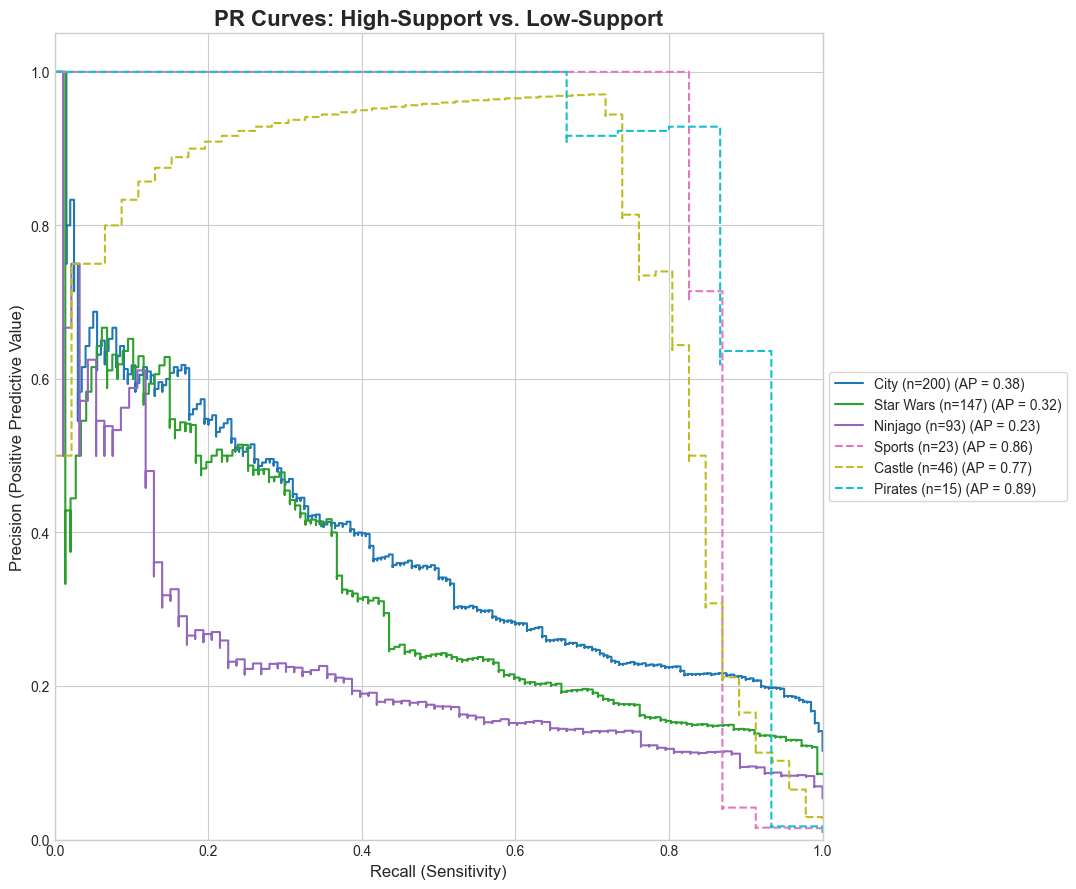

In [73]:
def plot_thesis_pr_curves_expanded(y_true, y_probs, labels):
    support = y_true.sum(axis=0)
    
    high_support_labels = ["City", "Star Wars", "Ninjago"]
    low_support_labels = ["Sports", "Castle","Pirates"]
    
    target_labels = high_support_labels + low_support_labels
    target_indices = [list(labels).index(l) for l in target_labels if l in labels]
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 9))
    
    colors = plt.cm.get_cmap('tab10', len(target_indices))
    
    for idx, i in enumerate(target_indices):
        linestyle = '-' if labels[i] in high_support_labels else '--'
        PrecisionRecallDisplay.from_predictions(
            y_true[:, i], 
            y_probs[:, i], 
            name=f"{labels[i]} (n={int(support[i])})", 
            ax=ax,
            linestyle=linestyle,
            color=colors(idx)
        )
    
    plt.title("PR Curves: High-Support vs. Low-Support", fontsize=16, fontweight='bold')
    plt.xlabel("Recall (Sensitivity)", fontsize=12)
    plt.ylabel("Precision (Positive Predictive Value)", fontsize=12)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize='medium')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.tight_layout()
    plt.show()

# Execution
plot_thesis_pr_curves_expanded(y_test_true, y_test_probs, MAJOR_LABELS)

shows the trade-off between Precision and Recall 
the curves for high-support themes like City and Star Wars appear as staircases and the curves for low-support themes (Adventurers, Cars, Basic) move in larger blocks
Even with only 15 samples, the Pirates theme achieved a great AP of 0.89- training successfully prevented the model from ignoring rare classes. 

City (AP=0.38): Performs the best of the 3 suggesting it has a more recognizable visual identity compared to the others.
Ninjago (AP=0.23): Has the lowest AP hardest high-support theme and likely contains a wide variety of colors and shapes that the model struggles to find a single unifying feature, leading to high False Positive rates.

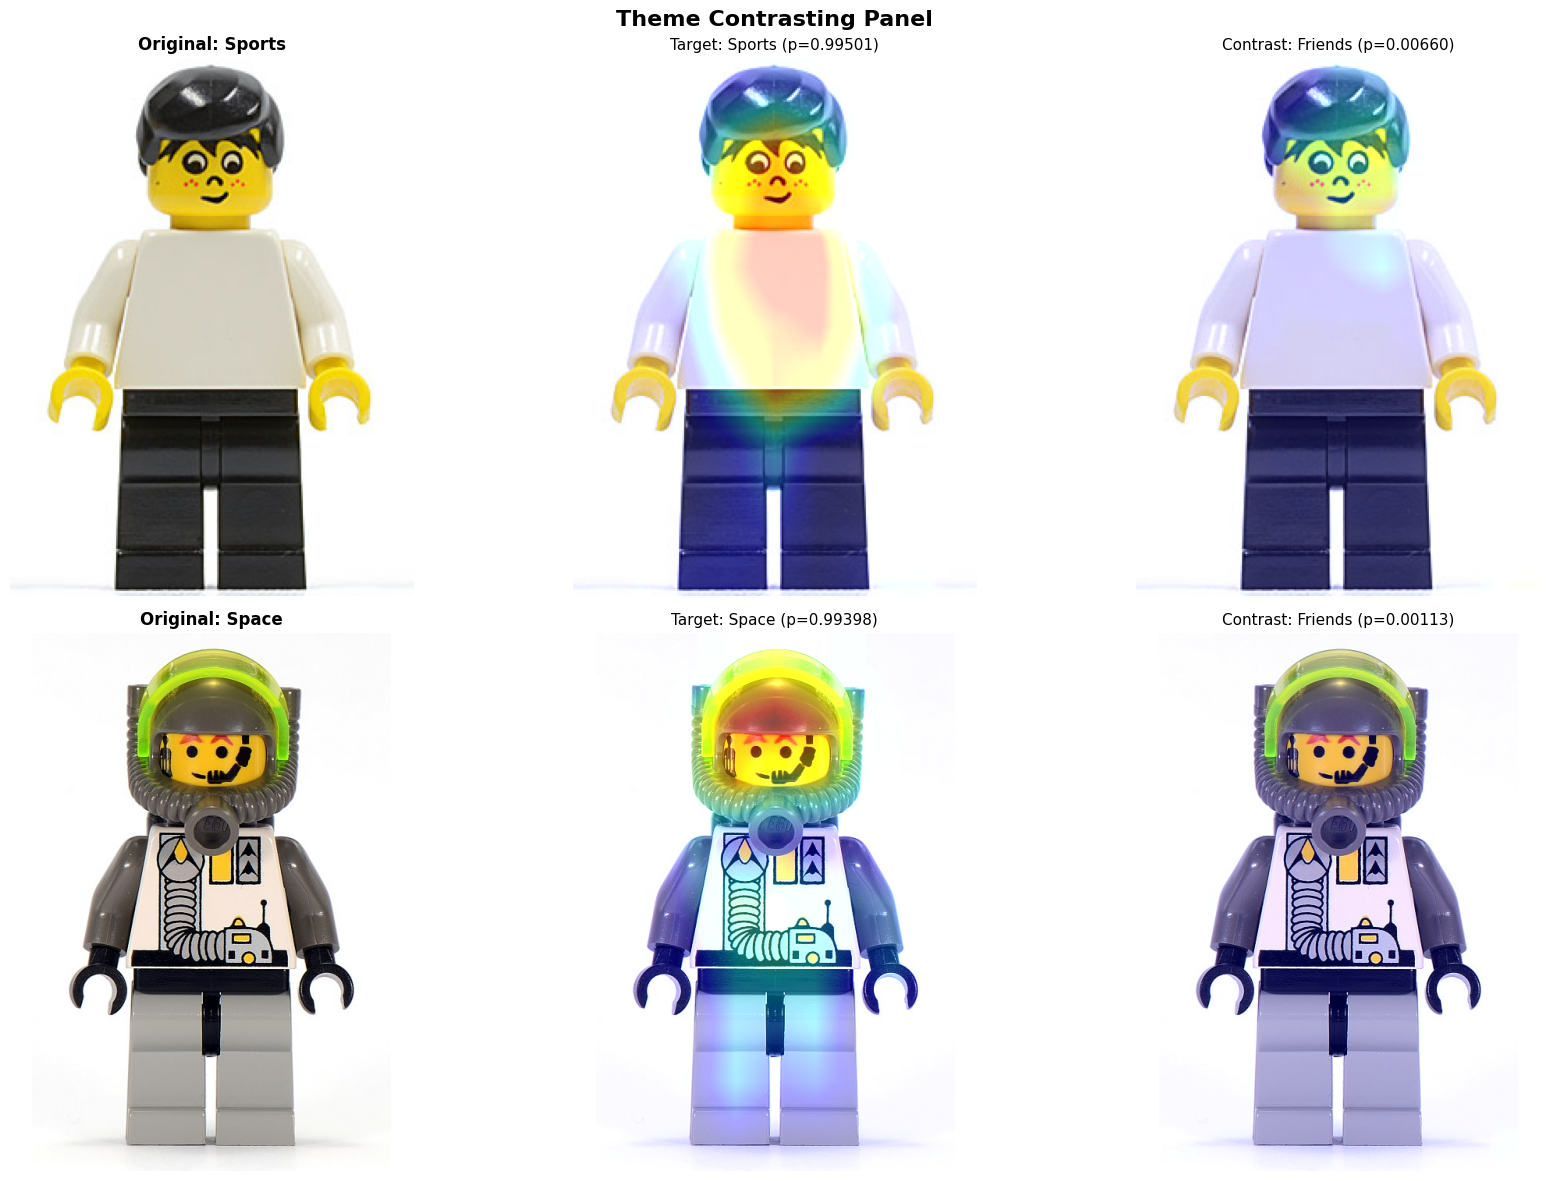

In [115]:
def preprocess_input_image(img_path, target_size=(260, 260)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    expanded_img = np.expand_dims(img_array, axis=0) # Shape becomes (1, 260, 260, 3)
    preprocessed_img = preprocess_input(expanded_img)
    return tf.convert_to_tensor(preprocessed_img, dtype=tf.float32)


def get_gradcam_heatmap_v2(model, img_input, last_conv_layer_name, pred_index):
   
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_input)
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0] 
    
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    
    heatmap = tf.maximum(heatmap, 0)
    return heatmap.numpy()


def visualize_cross_theme_contrast(model, themes_to_test, contrast_theme, last_conv_layer_name):
    all_labels = list(MAJOR_LABELS)
    contrast_idx = all_labels.index(contrast_theme)
    
    fig, axes = plt.subplots(len(themes_to_test), 3, figsize=(18, 6 * len(themes_to_test)))
    
    if len(themes_to_test) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for row_idx, theme in enumerate(themes_to_test):
        theme_idx = all_labels.index(theme)
        
        y_true = y_test_true[:, theme_idx]
        y_prob = y_test_probs[:, theme_idx]
        tp_indices = np.where((y_true == 1) & (y_prob > best_thresholds[theme_idx]))[0]
        
        img_idx = tp_indices[4]
        img_path = os.path.join(IMAGE_DIR, test_df_fixed.iloc[img_idx]['img_local_path'])
        
        img_orig = cv2.imread(img_path)
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        
        img_input = preprocess_input_image(img_path) 
        
        raw_predictions = model.predict(img_input, verbose=0)[0]
        target_conf = raw_predictions[theme_idx]
        contrast_conf = raw_predictions[contrast_idx]
        
        h_self_raw = get_gradcam_heatmap_v2(model, img_input, last_conv_layer_name, pred_index=theme_idx)
        h_star_raw = get_gradcam_heatmap_v2(model, img_input, last_conv_layer_name, pred_index=contrast_idx)
        
        h_self_log = np.log1p(h_self_raw * 100)
        h_star_log = np.log1p(h_star_raw * 100)
        
        global_max_scale = max(np.max(h_self_log), np.max(h_star_log)) + 1e-10
        
        h_self_normalized = h_self_log / global_max_scale
        h_star_normalized = h_star_log / global_max_scale
        

        axes[row_idx, 0].imshow(img_orig)
        axes[row_idx, 0].set_title(f"Original: {theme}", fontsize=12, fontweight='bold')
        
        res_s = cv2.resize(h_self_normalized, (img_orig.shape[1], img_orig.shape[0]))
        col_s = cv2.applyColorMap(np.uint8(255 * res_s), cv2.COLORMAP_JET)
        col_s = cv2.cvtColor(col_s, cv2.COLOR_BGR2RGB) 
        sup_s = np.clip((col_s * 0.4) + img_orig, 0, 255).astype(np.uint8)
        
        axes[row_idx, 1].imshow(sup_s)
        axes[row_idx, 1].set_title(f"Target: {theme} (p={target_conf:.5f})", fontsize=11)
        
        res_w = cv2.resize(h_star_normalized, (img_orig.shape[1], img_orig.shape[0]))
        col_w = cv2.applyColorMap(np.uint8(255 * res_w), cv2.COLORMAP_JET)
        col_w = cv2.cvtColor(col_w, cv2.COLOR_BGR2RGB)
        sup_w = np.clip((col_w * 0.4) + img_orig, 0, 255).astype(np.uint8)
        
        axes[row_idx, 2].imshow(sup_w)
        axes[row_idx, 2].set_title(f"Contrast: {contrast_theme} (p={contrast_conf:.5f})", fontsize=11)

    for ax in axes.flatten():
        ax.axis('off')
        
    plt.suptitle("Theme Contrasting Panel", fontsize=16, y=0.98, fontweight='bold')
    plt.tight_layout()
    plt.show()

test_themes = ["Sports", "Space"]
target_layer = "block7b_add"
visualize_cross_theme_contrast(model3, test_themes, "Friends", target_layer) 

Sports - Friends heatmap ignores the torso focusing instead on the face and hair trying to associate the facial features as Friends-like whereas the sports heatmap focuses on the areas where a jersey might give away the theme
Space - Friends detector skips this image because the probability is too low to light anything up 

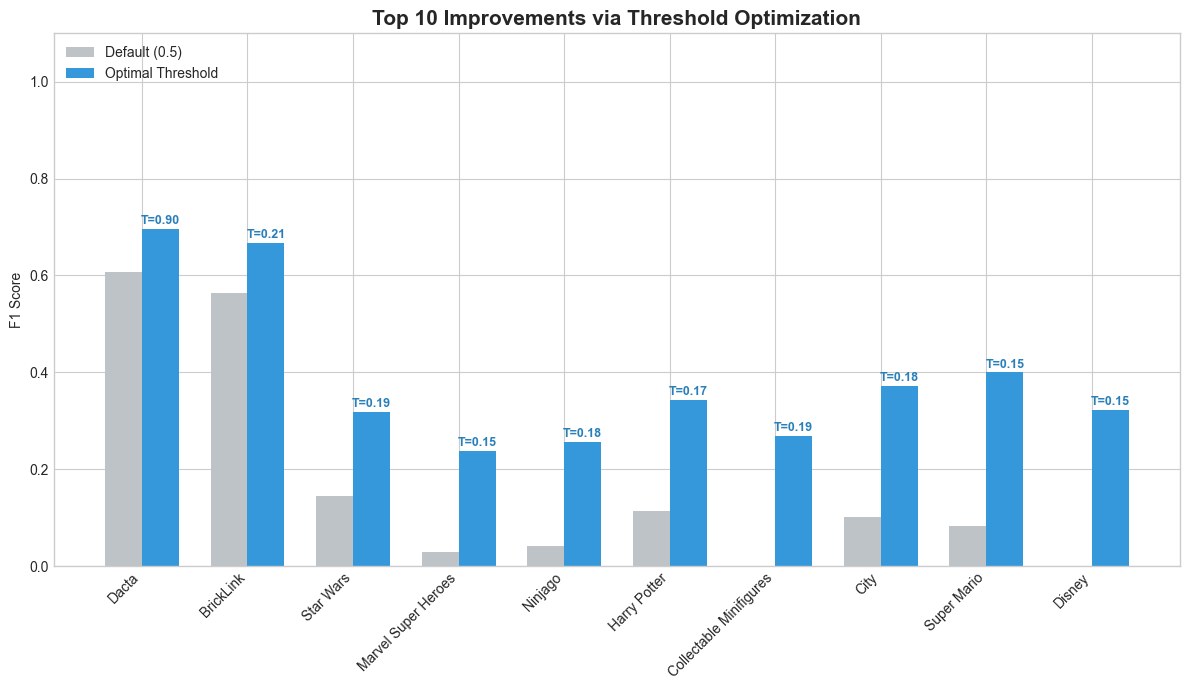

In [39]:
from sklearn.metrics import f1_score

def threshold_impact(y_true, y_pred_probs, opt_thresholds, labels, top_n=10):

    y_pred_default = (y_pred_probs >= 0.5).astype(int)
    y_pred_opt = (y_pred_probs >= opt_thresholds).astype(int)
    
    f1_default = f1_score(y_true, y_pred_default, average=None)
    f1_opt = f1_score(y_true, y_pred_opt, average=None)
    
    improvement = f1_opt - f1_default
    indices = np.argsort(improvement)[-top_n:] 
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 7))
    
    x = np.arange(len(indices))
    width = 0.35
    
    plt.bar(x - width/2, f1_default[indices], width, label='Default (0.5)', color='#bdc3c7')
    plt.bar(x + width/2, f1_opt[indices], width, label='Optimal Threshold', color='#3498db')
    
    for i, idx in enumerate(indices):
        plt.text(x[i] + width/2, f1_opt[idx] + 0.01, f"T={opt_thresholds[idx]:.2f}", 
                 ha='center', fontsize=9, fontweight='bold', color='#2980b9')

    plt.xticks(x, [labels[i] for i in indices], rotation=45, ha='right')
    plt.ylabel('F1 Score')
    plt.ylim([0, 1.1])
    plt.title(f'Top 10 Improvements via Threshold Optimization', fontsize=15, fontweight='bold')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

threshold_impact(y_test_true, y_test_probs, best_thresholds, MAJOR_LABELS)

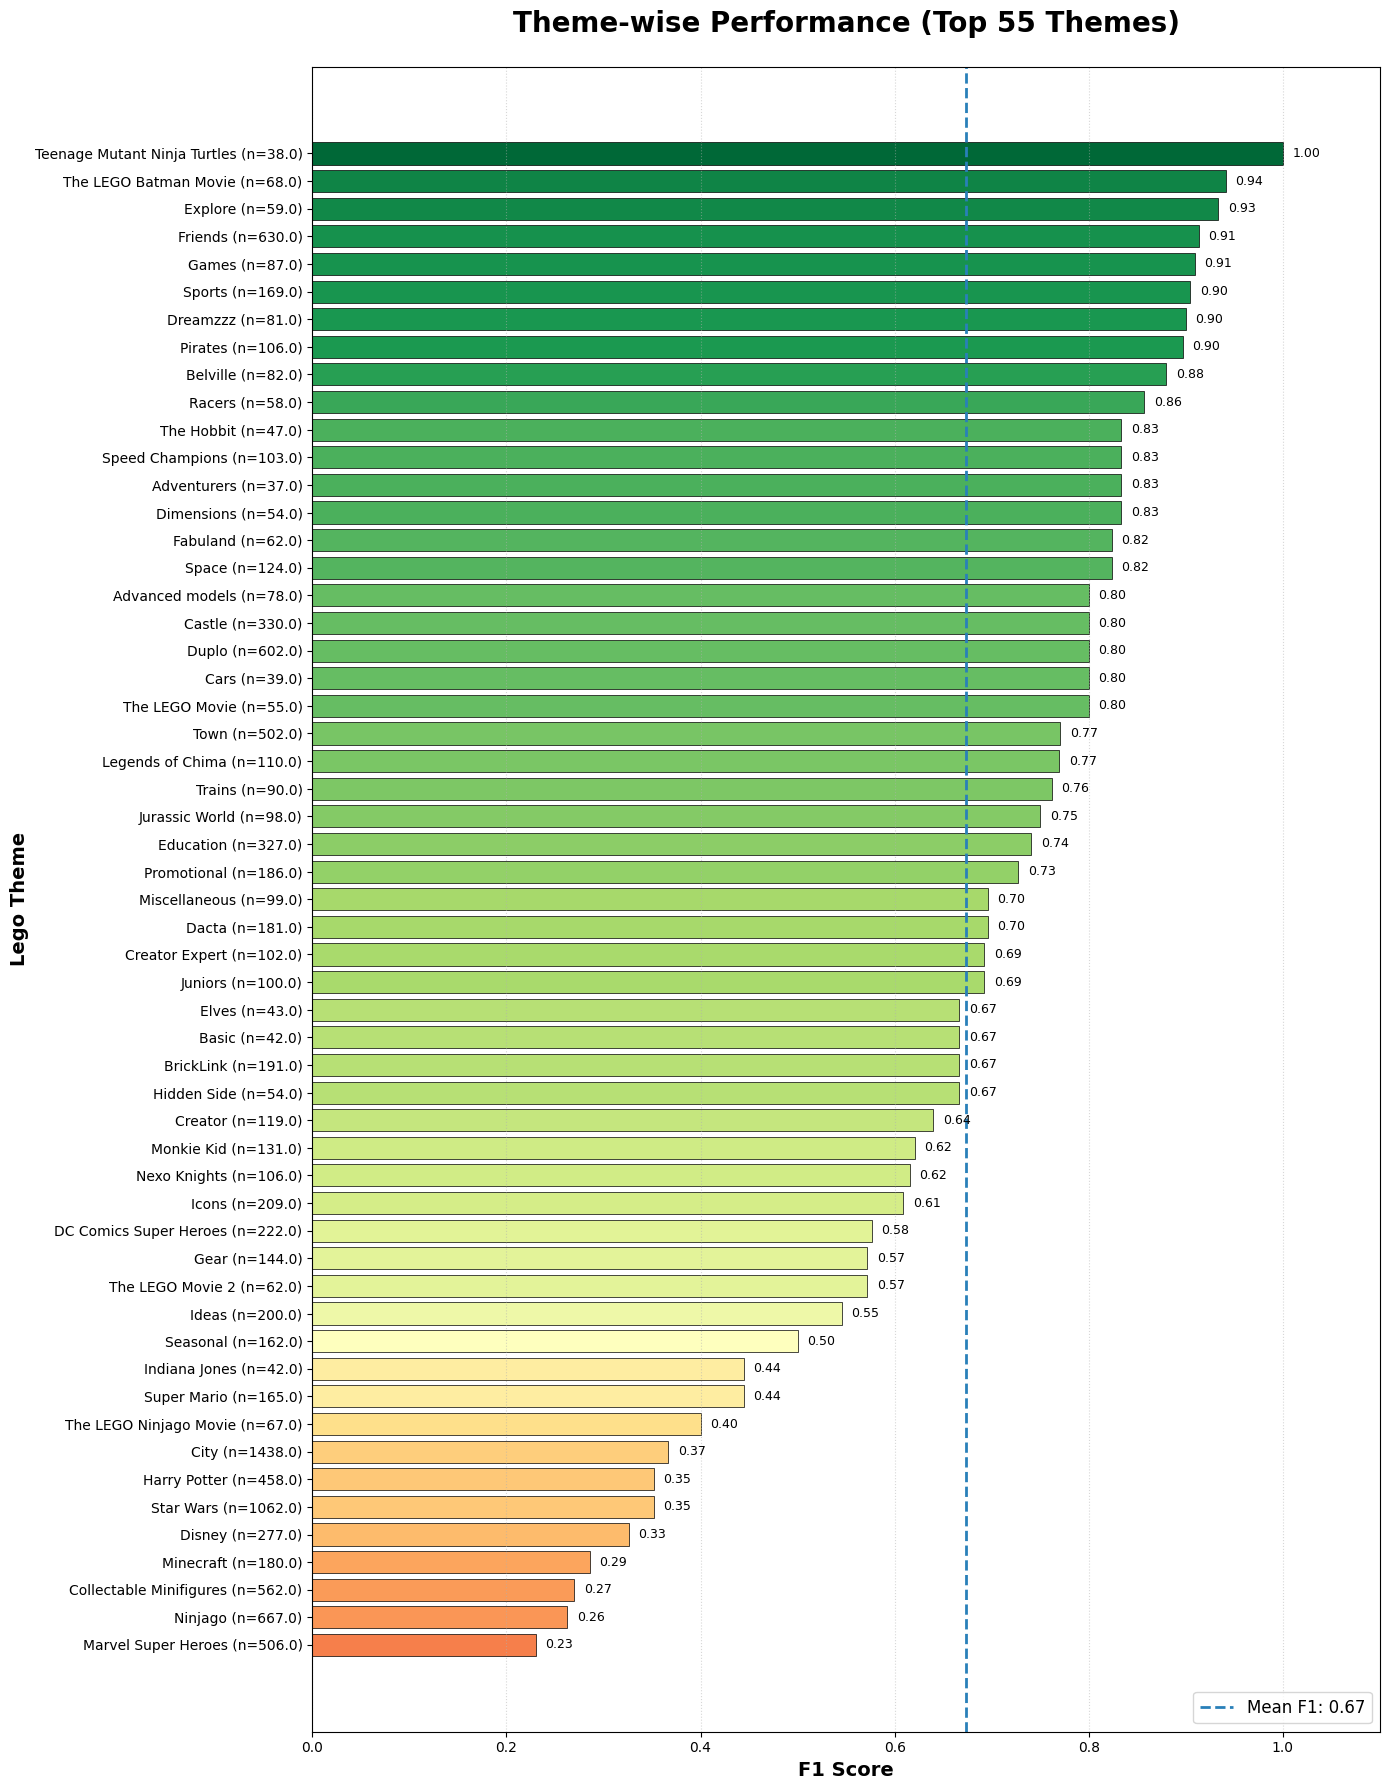

In [38]:
theme_columns = [col for col in train_df.columns if col != 'img_local_path']
train_counts = train_df[theme_columns].sum().to_dict()

# Top 55 Themes 
test_support = test_df_fixed[MAJOR_LABELS].sum().sort_values(ascending=False)
top_55_names = test_support.head(55).index.tolist()
top_55_indices = [list(MAJOR_LABELS).index(name) for name in top_55_names]

y_test_true_55 = y_test_true[:, top_55_indices]
y_test_probs_55 = y_test_probs[:, top_55_indices]

if isinstance(best_thresholds, list):
    best_thresholds_55 = np.array(best_thresholds)[top_55_indices]
else:
    best_thresholds_55 = best_thresholds[top_55_indices]

MAJOR_LABELS_55 = [MAJOR_LABELS[i] for i in top_55_indices]


def plot_f1_top55(y_true, y_pred_probs, opt_thresholds, labels, train_counts):
    opt_thresholds = np.array(opt_thresholds)
    
    y_pred_opt = (y_pred_probs >= opt_thresholds).astype(int)
    f1_scores = f1_score(y_true, y_pred_opt, average=None)
    
    sorted_indices = np.argsort(f1_scores)
    sorted_f1 = f1_scores[sorted_indices]
    
    sorted_labels = []
    for i in sorted_indices:
        theme_name = labels[i]
        support = train_counts.get(theme_name, 0)
        sorted_labels.append(f"{theme_name} (n={support})")
    
    colors = cm.RdYlGn(sorted_f1) 
    
    fig, ax = plt.subplots(figsize=(14, 18))
    bars = ax.barh(sorted_labels, sorted_f1, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('F1 Score', fontsize=14, fontweight='bold')
    ax.set_ylabel('Lego Theme', fontsize=14, fontweight='bold')
    ax.set_title('Theme-wise Performance (Top 55 Themes)', fontsize=20, fontweight='bold', pad=25)
    
    mean_f1 = np.mean(f1_scores)
    ax.axvline(mean_f1, color='#2980b9', linestyle='--', linewidth=2, label=f'Mean F1: {mean_f1:.2f}')
    
    ax.set_xlim([0, 1.1])
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.legend(loc='lower right', fontsize=12)
    
    for i, v in enumerate(sorted_f1):
        ax.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9)
        
    plt.tight_layout()
    
    plt.show()

plot_f1_top55(y_test_true_55, y_test_probs_55, best_thresholds_55, MAJOR_LABELS_55, train_counts)

In [65]:
valid_row_mask = y_test_true.sum(axis=1) > 0
y_test_true_clean = y_test_true[valid_row_mask]
y_test_pred_clean = y_test_pred_opt[valid_row_mask]

top_55_detailed = metrics_df.sort_values(by='Support', ascending=False).head(55)
top_55_names_clean = top_55_detailed['Theme'].tolist()
top_55_indices_clean = [list(MAJOR_LABELS).index(name) for name in top_55_names_clean]

y_test_true_55_clean = y_test_true_clean[:, top_55_indices_clean]
y_test_pred_55_clean = y_test_pred_clean[:, top_55_indices_clean]

labels_per_image_clean = y_test_true_clean.sum(axis=1)
slice_results_clean = []

for k in sorted(np.unique(labels_per_image_clean)):
    idx = np.where(labels_per_image_clean == k)[0]
    f1 = f1_score(y_test_true_clean[idx], y_test_pred_clean[idx], average="macro", zero_division=0)
    slice_results_clean.append({
        "labels_per_image": int(k),
        "n_samples"        : len(idx),
        "macro_f1"         : round(f1, 4)
    })

print("Performance by number of labels per image:")
display(pd.DataFrame(slice_results_clean))

Performance by number of labels per image:


,labels_per_image,n_samples,macro_f1
0,1,1608,0.6010
1,2,47,0.2912
2,3,5,0.0622
3,4,1,0.0000


Comparison Against Chloe's

In [42]:
generator_to_use = test_generator3  
generator_to_use.reset() 
predictions = model3.predict(generator_to_use)

y_val_true = test_df_fixed[MAJOR_LABELS].values 
filenames = generator_to_use.filenames

109/109 ━━━━━━━━━━━━━━━━━━━━ 80s 735ms/step


In [43]:
sw_idx = MAJOR_LABELS.index('Star Wars')
basic_idx = MAJOR_LABELS.index('Basic')

pred_star_wars = (predictions[:, sw_idx] > best_thresholds[sw_idx]).astype(int)
pred_basic = (predictions[:, basic_idx] > best_thresholds[basic_idx]).astype(int)

true_star_wars = y_val_true[:, sw_idx]
true_basic = y_val_true[:, basic_idx]

df_eval = pd.DataFrame({
    'filename': filenames,
    'true_sw': true_star_wars,
    'pred_sw': pred_star_wars,
    'true_basic': true_basic,
    'pred_basic': pred_basic
})
sw_true_positives  = df_eval[(df_eval['true_sw'] == 1) & (df_eval['pred_sw'] == 1)]
sw_false_positives = df_eval[(df_eval['true_sw'] == 0) & (df_eval['pred_sw'] == 1)]
sw_false_negatives = df_eval[(df_eval['true_sw'] == 1) & (df_eval['pred_sw'] == 0)]

basic_true_positives  = df_eval[(df_eval['true_basic'] == 1) & (df_eval['pred_basic'] == 1)]
basic_false_positives = df_eval[(df_eval['true_basic'] == 0) & (df_eval['pred_basic'] == 1)]
basic_false_negatives = df_eval[(df_eval['true_basic'] == 1) & (df_eval['pred_basic'] == 0)]

print(f"Star Wars -> TP: {len(sw_true_positives)} | FP: {len(sw_false_positives)} | FN: {len(sw_false_negatives)}")
print(f"Basic     -> TP: {len(basic_true_positives)} | FP: {len(basic_false_positives)} | FN: {len(basic_false_negatives)}")

Star Wars -> TP: 64 | FP: 153 | FN: 83
Basic     -> TP: 4 | FP: 2 | FN: 2


In [44]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import os
import matplotlib.pyplot as plt

def plot_theme_trio(model, theme_name, class_list, tp_df, fp_df, fn_df, val_img_dir, target_size=(260, 260)):
    try:
        target_class_idx = class_list.index(theme_name)
    except ValueError:
        print(f"Error: {theme_name} not found in the class list.")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Grad-CAM Panel: {theme_name.upper()} Theme", fontsize=16, fontweight='bold', y=1.02)
    
    def render_subplot(df, ax, title, color):
        if not df.empty:
            img_filename = df.iloc[0]['filename']
            p = os.path.join(val_img_dir, img_filename)
            
            if os.path.exists(p):
                cam_overlay, _ = get_refined_cam(model, p, target_class_idx, target_size)
                ax.imshow(cam_overlay)
                ax.set_title(f"{title}\n{img_filename}", color=color, fontsize=10)
            else:
                ax.text(0.5, 0.5, f'File Not Found:\n{img_filename}', ha='center', va='center', fontsize=8)
        else:
            ax.text(0.5, 0.5, f'No {title} Data', ha='center', va='center')
        ax.axis('off')

    # Plot the Trio
    render_subplot(tp_df, axes[0], "True Positive", "green")
    render_subplot(fp_df, axes[1], "False Positive (Type I)", "red")
    render_subplot(fn_df, axes[2], "False Negative (Type II)", "darkorange")

    plt.tight_layout()
    plt.show()

C:\Users\athul\anaconda3\envs\bda3\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_345']]
Received: inputs=Tensor(shape=(1, 260, 260, 3))
  warnings.warn(msg)


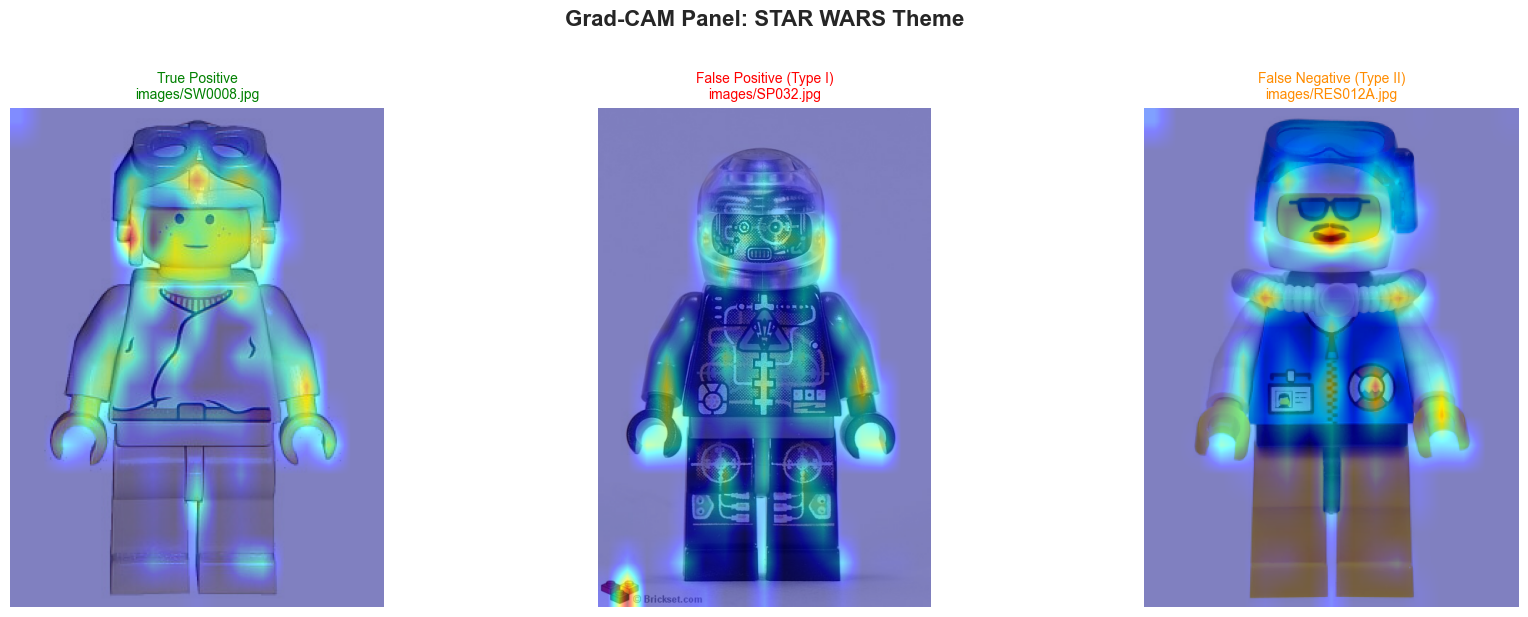

In [50]:
IMAGE_DIR = r'C:\Users\athul\lego'
plot_theme_trio(model3, "Star Wars", MAJOR_LABELS, sw_true_positives, sw_false_positives, sw_false_negatives, IMAGE_DIR)

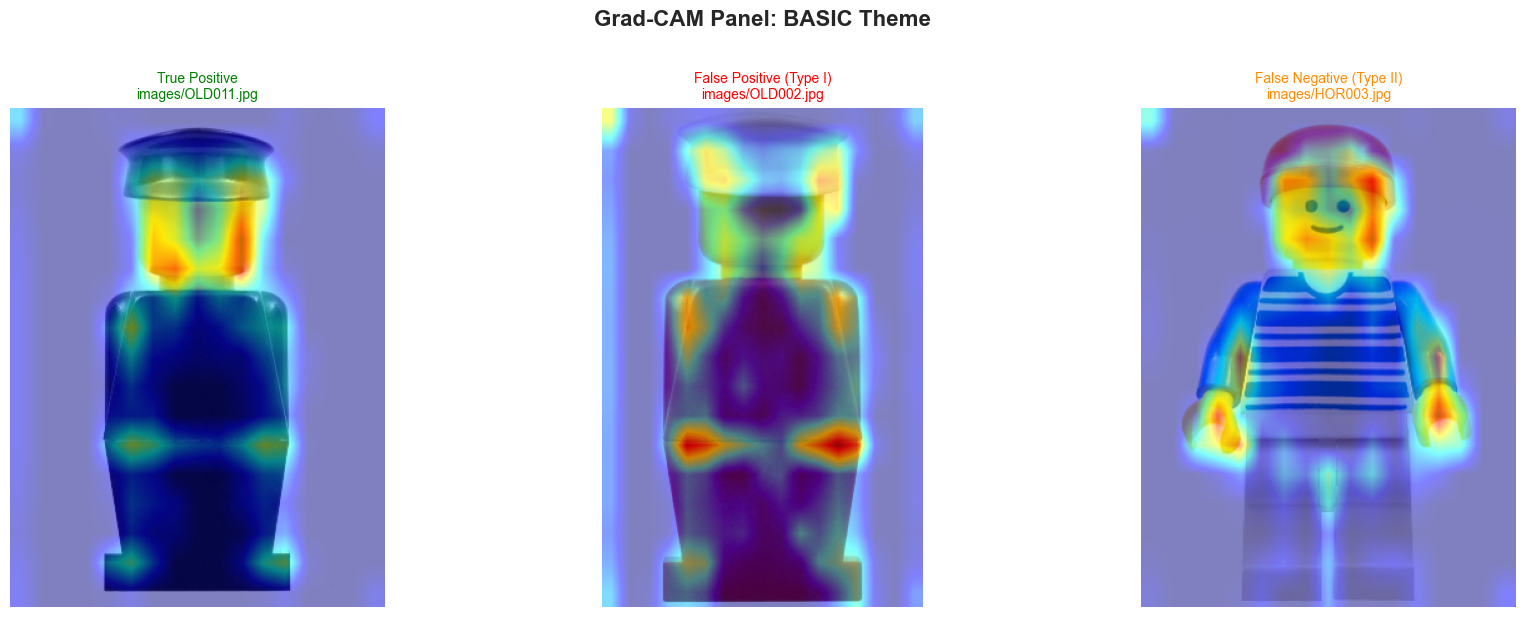

In [51]:
plot_theme_trio(model3, "Basic", MAJOR_LABELS, basic_true_positives, basic_false_positives, basic_false_negatives, IMAGE_DIR)

NOT PULLING UP THE RIGHT TEST FILE - POSSIBLE CORRECTION IN LABELS FOR TEST FILES 
UNABLE TO TRIAGE THE ISSUE IN TIME

EfficientNet uses a compound scaling method that balances network depth, width, and resolution & identifies fine-grained details by utilizing MBConv (Mobile Inverted Bottleneck Convolution) blocks, which focus on spatial patterns.
SW
TP - heat is concentrated on the side of the helmet and the asymmetrical torso (unique geometric feature) 
ignores the plain legs and is trying to hone in on the more unique features

FP- Space theme so close enough for it to get wrong which is a good sign i suppose
heat on the faceplate and the central torso and so it thought it was SW

FN - town
heat is on the goggles and the collar but it has a lot of embellishments much like SW which tricks the model
focusing on goggles—a feature common in City, Town and Star Wars -->leads to high False Positives 

BASIC
the absence of complex details is the defining feature which is difficult for the model to actually learn 

TP 
concentrated intensely on the neck/face area and the bottom corners of the feet
learning that the yellow head and the plain, unprinted torso is a basic feature however this is also shared by legoland and other themes

FP - legoland which is also quite similar to basic so again makes sense
hotspots on the hands/wrists and the hat brim -has a very simple silhouette (similar to basic)

FN
looking at the face (cheeks) and the hands, but ignored the striped torso
high-contrast horizontal stripes confused it since it probably deemed it too complex to be BASIC

model was never confident about themes like Basic and could only flag them at low thresholds due to the lack of confidence because of the bg focus and the weak guesses being made creates a lot of False Positives

Themes like Friends (0.913), Duplo (0.800), and Batman (0.941) have genuinely high scores -> strong visual outliers
Friends -> vibrant colors (purple/teal/pink) that don't exist in the others
Duplo/Explore -> larger, rounded blocks
Batman -> distinctive accessories and headgear

EfficientNetB2 architecture is excellent at finding shape-based signatures
Because City and Star Wars made up a huge portion of training data, the model became biased toward them
has learned to identify shapes like Batman and Duplo quite well
overfitting to the background for common themes

In [73]:
test_preds_raw = model3.predict(test_generator3)

results_dict = {'filename': test_generator3.filenames}

for i, label in enumerate(MAJOR_LABELS):
    thresh = best_thresholds[i]
    results_dict[f'prob_{label}'] = test_preds_raw[:, i]
    results_dict[f'pred_{label}'] = (test_preds_raw[:, i] >= thresh).astype(int)

df_test_results = pd.DataFrame(results_dict)

multi_label_hits = df_test_results[df_test_results[[f'pred_{l}' for l in MAJOR_LABELS]].sum(axis=1) > 1]
print(f"Found {len(multi_label_hits)} images with multiple theme detections.")

109/109 [==============================] - 151s 1s/step
Found 481 images with multiple theme detections.


In [79]:
binary_preds = (test_preds_raw >= best_thresholds).astype(int)

y_true = np.array(test_generator3.labels)

def map_to_names(binary_row, labels):
    active_themes = [labels[i] for i, val in enumerate(binary_row) if val == 1]
    return ", ".join(active_themes) if active_themes else "None"

comparison_data = []
for i in range(len(test_generator3.filenames)):
    comparison_data.append({
        'filename': test_generator3.filenames[i],
        'Actual_Themes': map_to_names(y_true[i], MAJOR_LABELS),
        'Predicted_Themes': map_to_names(binary_preds[i], MAJOR_LABELS)
    })

df_comparison = pd.DataFrame(comparison_data)

df_multi_detections = df_comparison[df_comparison['Predicted_Themes'].str.contains(',')]
df_multi_detections.head(10)

,filename,Actual_Themes,Predicted_Themes
0,images/OLD011.jpg,"Basic, LEGOLAND","Basic, LEGOLAND"
3,images/OLD002.jpg,LEGOLAND,"Basic, LEGOLAND"
9,images/DUPFIG011.jpg,"Duplo, Dacta","Duplo, Dacta"
16,images/TRN068.jpg,"Dacta, Basic","Dacta, Basic"
22,images/CAS232.jpg,"Duplo, Dacta","Duplo, Dacta"
27,images/4555PB161.jpg,"Duplo, Dacta","Duplo, Dacta"
32,images/CAS113.jpg,"Town, Dacta","Town, Dacta"
51,images/OVR004.jpg,Town,"Town, Dacta"
53,images/DOC012.jpg,"Duplo, Dacta","Duplo, Dacta"
61,images/4555PB121.jpg,Duplo,"Duplo, Dacta"


In [82]:
error_summary = []

for i, label in enumerate(MAJOR_LABELS):
    tp = np.sum((binary_preds[:, i] == 1) & (y_true[:, i] == 1))
    tn = np.sum((binary_preds[:, i] == 0) & (y_true[:, i] == 0))
    fp = np.sum((binary_preds[:, i] == 1) & (y_true[:, i] == 0))
    fn = np.sum((binary_preds[:, i] == 0) & (y_true[:, i] == 1))
    
    error_summary.append({
        'Theme': label,
        'Correct (TP+TN)': tp + tn,
        'False Positives (Type I)': fp,
        'False Negatives (Type II)': fn,
        'Accuracy': (tp + tn) / len(y_true)
    })

df_errors = pd.DataFrame(error_summary)


In [83]:
df_errors.sort_values(by='False Positives (Type I)', ascending=False)

,Theme,Correct (TP+TN),False Positives (Type I),False Negatives (Type II),Accuracy
0,City,1275,395,64,0.735294
1,Star Wars,1455,197,82,0.839100
6,Marvel Super Heroes,1586,101,47,0.914648
2,Ninjago,1572,97,65,0.906574
5,Collectable Minifigures,1603,77,54,0.924452
...,...,...,...,...,...
52,Cars,1732,0,2,0.998847
43,Explore,1733,0,1,0.999423
49,Elves,1731,0,3,0.998270
48,The Hobbit,1732,0,2,0.998847


model that is a specialist in unique shapes but a struggling generalist 
Early in training, it mastered the features that are unambiguous
For City and more plain figures, the model couldn't easily find a distinct differentiatior and so it settled for background bias 
optimal threshold resulted in higher FPs but can also be reverted if we wanted to generalise better since it only resulted in a 3% gain

MBConv blocks are designed to capture fine-grained spatial relationships -> unique shapes are locked onto quickly
successfully identifies 55 different themes with a 67% average accuracy
great tool for identifying specialized figures
relies too heavily on the specific photography setup

Loss Function: Binary Cross-Entropy (BCE)
treats every theme as an independent Bernoulli trial (Yes/No)
allowed the model to learn that a figure could be A and B simultaneously
themes not present far outnumber the ones where it does show up 
class Weights boosted the gradients of the rare themes & focus on rarer images which would otherwise had gotten drowned out 
for common themes per-sample penalty was lower and so it went for simpler, halo-like features
Focal Loss for fine-tuning also down-weights easy examples and focused on hard ones

Majority Bias (City/Star Wars) --> learn background if similar since it is the easiest way to lower the loss
Minority Bias (Batman/TMNT) --> few samples allow memorisation of unique geometry

Threshold Optimization -> double edged sword because lowering helps capture weak signals but lowers precision due to explosion of false positives
can switch these up and back to 0.5 (without too much of a drop in F1) to keep guesses more accurate and rigid

Global Average Pooling at the end found that the pixels in the corners had a higher correlation with the Star Wars label than in center